# Bibliotecas

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

from statsmodels.tsa.stattools import adfuller

from statsmodels.tsa.api import VAR
import pandas as pd

---

## 1. Procesamiento y Análisis Exploratorio de Datos (EDA)
En esta sección se realiza la ingesta de los datos macroeconómicos extraídos de la API de **Banxico** y su transformación para el análisis de series de tiempo.

### Objetivos técnicos:
*   **Alineación de Frecuencias:** Dado que las variables (TIIE, Tipo de Cambio e INPC) tienen distintas periodicidades de publicación, se realiza una **mensualización** de las series utilizando promedios para las tasas y el último valor observado para el índice de precios.
*   **Ingeniería de Variables:** Cálculo de la **Inflación Anual** mediante la variación porcentual del INPC con respecto al mismo mes del año anterior.
*   **Limpieza Estructural:** Manejo de valores nulos y asegurar el ordenamiento cronológico para evitar sesgos en el modelo predictivo.

## 2. Visualización: Dinámica Tasa vs. Inflación
El siguiente gráfico permite observar la relación histórica entre el instrumento de política monetaria (**TIIE a 28 días**) y el objetivo de estabilidad de precios (**Inflación**).

### Componentes del Análisis Visual:
*   **Doble Eje Y:** Comparativa directa de series con diferentes escalas porcentuales.
*   **Líneas de Tendencia:** Se incorporan regresiones lineales para identificar la dirección de largo plazo de ambas variables, mitigando el ruido de la volatilidad mensual.
*   **Contexto de Transmisión:** Esta visualización es el primer paso para identificar si los ciclos restrictivos (subidas de tasa) han sido efectivos para anclar las expectativas inflacionarias.

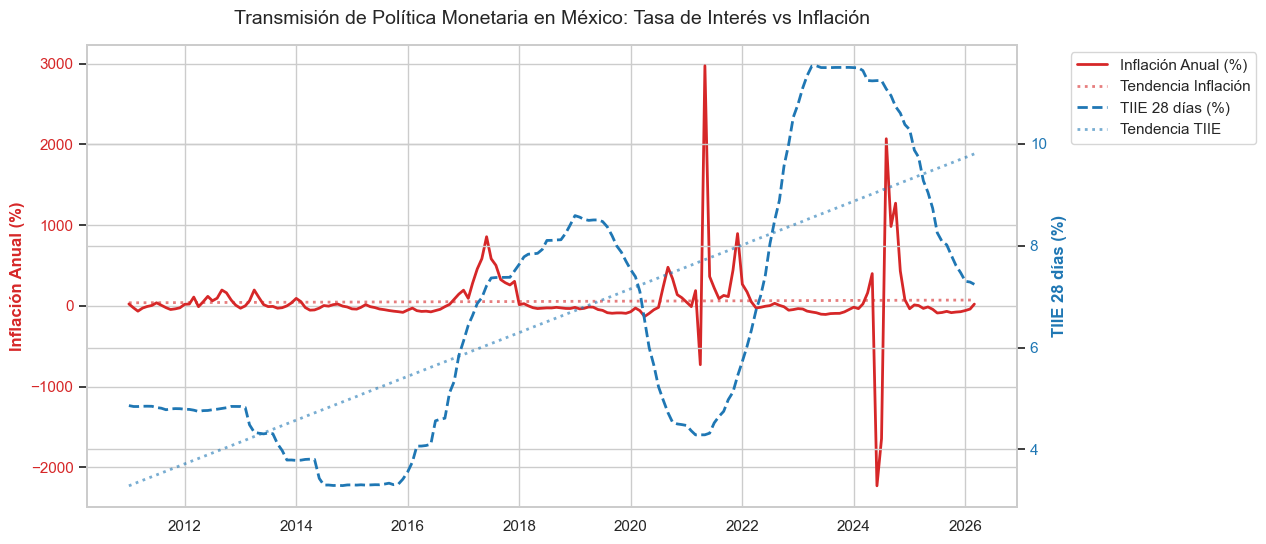

In [2]:
# Configurar estilo de los gráficos
sns.set_theme(style="whitegrid")

# 1. Cargar datos
df = pl.read_csv("../data/raw/datos_macro_mexico.csv")
df = df.with_columns(pl.col("Fecha").cast(pl.Date)).sort("Fecha")

# 2. Alinear frecuencias (Mensualizar)
df_mensual = df.group_by_dynamic(
    "Fecha", every="1mo"
).agg([
    pl.col("TIIE_28").drop_nulls().mean(),
    pl.col("Tipo_Cambio_FIX").drop_nulls().mean(),
    pl.col("INPC").drop_nulls().last() # <-- Toma el último dato real del mes
])

# 3. Calcular la Inflación Anual
df_mensual = df_mensual.with_columns(
    Inflacion_Anual = ((pl.col("INPC") / pl.col("INPC").shift(12)) - 1) * 100
).drop_nulls() 

# 4. Visualización Dual: Tasa vs Inflación
fig, ax1 = plt.subplots(figsize=(12, 6))

# --- Método infalible: Índices numéricos ---
x_indices = np.arange(len(df_mensual))
y_inflacion = df_mensual["Inflacion_Anual"].to_numpy()
y_tasa = df_mensual["TIIE_28"].to_numpy()

# ================= EJE IZQUIERDO: INFLACIÓN =================
color1 = '#D62728' 
# Línea real
ax1.plot(df_mensual["Fecha"], df_mensual["Inflacion_Anual"], color=color1, linewidth=2, label='Inflación Anual (%)')
# Línea de tendencia
z1 = np.polyfit(x_indices, y_inflacion, 1)
p1 = np.poly1d(z1)
ax1.plot(df_mensual["Fecha"], p1(x_indices), color=color1, linestyle=':', alpha=0.6, linewidth=2, label='Tendencia Inflación')

ax1.set_ylabel('Inflación Anual (%)', color=color1, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color1)

# ================= EJE DERECHO: TIIE =================
ax2 = ax1.twinx()  
color2 = '#1F77B4' 
# Línea real
ax2.plot(df_mensual["Fecha"], df_mensual["TIIE_28"], color=color2, linewidth=2, linestyle='--', label='TIIE 28 días (%)')
# Línea de tendencia
z2 = np.polyfit(x_indices, y_tasa, 1)
p2 = np.poly1d(z2)
ax2.plot(df_mensual["Fecha"], p2(x_indices), color=color2, linestyle=':', alpha=0.6, linewidth=2, label='Tendencia TIIE')

ax2.set_ylabel('TIIE 28 días (%)', color=color2, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color2)

# ================= DETALLES FINALES =================
plt.title('Transmisión de Política Monetaria en México: Tasa de Interés vs Inflación', fontsize=14, pad=15)

# Juntar las leyendas
lineas1, etiquetas1 = ax1.get_legend_handles_labels()
lineas2, etiquetas2 = ax2.get_legend_handles_labels()
ax1.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc="upper left", bbox_to_anchor=(1.05, 1))

# 5. Guardar todo
os.makedirs("../data/processed", exist_ok=True)
plt.savefig("../data/tasa_vs_inflacion.png", dpi=300, bbox_inches='tight')
plt.show()

df_mensual.write_csv("../data/processed/datos_mensuales_limpios.csv")

---

## 3. Análisis de Estacionariedad (Prueba Dickey-Fuller Aumentada)

Antes de proceder con el modelado econométrico de series de tiempo (VAR) o algoritmos de Machine Learning, es fundamental validar la **estacionariedad** de las variables. Una serie es estacionaria cuando sus propiedades estadísticas, como la media y la varianza, son constantes en el tiempo.

### Justificación Técnica:
*   **Evitar Regresiones Espurias:** El uso de variables no estacionarias puede generar correlaciones artificiales que no representan una relación económica real.
*   **Prueba ADF:** Se implementa la prueba **Dickey-Fuller Aumentada** bajo la hipótesis nula ($H_0$) de que la serie posee una raíz unitaria (no es estacionaria).
*   **Criterio de Decisión:** Se utiliza un nivel de significancia estándar del **5%**. Un *p-value* $< 0.05$ indica que la serie es estacionaria ($I(0)$).

### Implementación del Test:
En este bloque se define una función automatizada para evaluar la **Inflación Anual** y la **TIIE a 28 días**, determinando si requieren una transformación mediante primeras diferencias para ser integradas al modelo predictivo.

In [3]:
# Función para realizar e interpretar la prueba ADF
def probar_estacionariedad(serie_tiempo, nombre_variable):
    print(f"--- Prueba Dickey-Fuller Aumentada para: {nombre_variable} ---")
    
    # Realizar la prueba
    resultado = adfuller(serie_tiempo, autolag='AIC')
    
    estadistico_adf = resultado[0]
    p_valor = resultado[1]
    
    print(f"Estadístico ADF: {estadistico_adf:.4f}")
    print(f"Valor p (p-value): {p_valor:.4f}")
    
    # Interpretación estándar (Nivel de significancia del 5%)
    if p_valor < 0.05:
        print("✅ Conclusión: Rechazamos la hipótesis nula. La serie ES ESTACIONARIA.\n")
    else:
        print("❌ Conclusión: No podemos rechazar la hipótesis nula. La serie NO ES ESTACIONARIA (Tiene raíz unitaria).\n")

# Extraer las series limpias en formato Numpy para la prueba
inflacion = df_mensual["Inflacion_Anual"].to_numpy()
tasa = df_mensual["TIIE_28"].to_numpy()

# Ejecutar las pruebas
probar_estacionariedad(inflacion, "Inflación Anual")
probar_estacionariedad(tasa, "TIIE a 28 días")

--- Prueba Dickey-Fuller Aumentada para: Inflación Anual ---
Estadístico ADF: -11.1047
Valor p (p-value): 0.0000
✅ Conclusión: Rechazamos la hipótesis nula. La serie ES ESTACIONARIA.

--- Prueba Dickey-Fuller Aumentada para: TIIE a 28 días ---
Estadístico ADF: -2.5148
Valor p (p-value): 0.1119
❌ Conclusión: No podemos rechazar la hipótesis nula. La serie NO ES ESTACIONARIA (Tiene raíz unitaria).



---

## 4. Transformación de Series: Estacionariedad mediante Diferenciación

Tras los resultados de la prueba ADF, se identificó que la **TIIE a 28 días** presenta una raíz unitaria (no es estacionaria en niveles). Para corregir esto y cumplir con los supuestos del modelo **VAR**, se procede a transformar la serie utilizando **Primeras Diferencias**.

### Objetivos de la Transformación:
*   **Diferenciación ($I(1) \to I(0)$):** Al calcular el cambio mensual de la tasa en lugar de su nivel absoluto, eliminamos la tendencia y la memoria de largo plazo de la serie.
*   **Interpretación Económica:** El modelo pasará de analizar el nivel de la tasa a analizar el **impacto de los cambios** (subidas o bajadas de puntos base) realizados por el Banco de México.
*   **Validación:** Se reevalúa la serie transformada con la prueba Dickey-Fuller para confirmar que el valor p sea ahora menor al **5%**.

### Flujo de Trabajo:
1.  Aplicación de la función `.diff()` sobre la columna `TIIE_28`.
2.  Eliminación de valores nulos generados por el desfase temporal.
3.  Persistencia de los datos finales en `datos_mensuales_limpios.csv` para asegurar la reproducibilidad en las etapas de modelado y Machine Learning.

In [4]:
# --- Transformación a Primeras Diferencias ---
print("Transformando la TIIE para alcanzar estacionariedad...\n")

# Calculamos la diferencia: TIIE del mes actual menos TIIE del mes anterior
df_mensual = df_mensual.with_columns(
    TIIE_28_Diff = pl.col("TIIE_28").diff()
).drop_nulls() # El primer mes se volverá nulo porque no tiene mes anterior para restarse

# Extraemos la nueva serie limpia
tasa_diff = df_mensual["TIIE_28_Diff"].to_numpy()

# Volvemos a probar estacionariedad en la nueva variable
probar_estacionariedad(tasa_diff, "Cambio Mensual en TIIE (1ra Diferencia)")

# Actualizamos nuestro archivo procesado para que el modelo lo lea
df_mensual.write_csv("../data/processed/datos_mensuales_limpios.csv")
print("Archivo procesado actualizado con las variables estacionarias.")

Transformando la TIIE para alcanzar estacionariedad...

--- Prueba Dickey-Fuller Aumentada para: Cambio Mensual en TIIE (1ra Diferencia) ---
Estadístico ADF: -3.0025
Valor p (p-value): 0.0347
✅ Conclusión: Rechazamos la hipótesis nula. La serie ES ESTACIONARIA.

Archivo procesado actualizado con las variables estacionarias.


---

## 5. Especificación y Ajuste del Modelo VAR (Vectores Autorregresivos)

En esta fase se implementa un modelo de **Vectores Autorregresivos (VAR)** para capturar las interdependencias dinámicas entre la **Inflación Anual** y el **Cambio Mensual en la TIIE**. A diferencia de los modelos univariados, el VAR trata a ambas variables como endógenas, permitiendo analizar cómo se afectan mutuamente a lo largo del tiempo.

### Metodología de Implementación:
*   **Selección de Rezagos (Lag Selection):** Se evalúa el número óptimo de meses de historia necesarios para el modelo utilizando criterios de información estadística (AIC, BIC, HQIC). En este caso, el criterio de **Akaike (AIC)** determinó que **2 meses** es la profundidad histórica ideal para balancear la precisión y la parsimonia del modelo.
*   **Ajuste del Modelo:** Se entrena el sistema de ecuaciones simultáneas utilizando los rezagos seleccionados para obtener los coeficientes de regresión y las estadísticas de significancia.
*   **Finalidad Académica:** Este enfoque es fundamental para entender la persistencia de los choques macroeconómicos y constituye la base para generar las Funciones de Impulso-Respuesta (IRF), herramientas clave en el análisis de política monetaria.

### Diagnóstico del Modelo:
El resumen estadístico generado permite validar la bondad de ajuste y la relevancia de los rezagos de cada variable, proporcionando una visión técnica de la "memoria" del sistema económico analizado.

In [5]:
print("--- Configurando el Modelo VAR ---\n")

# 1. Preparar la matriz de datos
# Extraemos solo las variables estacionarias y las pasamos a Pandas (formato preferido por statsmodels)
datos_var = df_mensual.select(["Inflacion_Anual", "TIIE_28_Diff"]).to_pandas()

# 2. Inicializar el modelo
modelo_var = VAR(datos_var)

# 3. Selección automática del número de rezagos (lags)
# Le pedimos que pruebe mirando desde 1 hasta 12 meses hacia atrás
seleccion_lags = modelo_var.select_order(maxlags=12)

print("Tabla de Criterios de Información (Buscamos los asteriscos *):")
print(seleccion_lags.summary())

# Extraemos el número de rezagos óptimo según el criterio AIC
lags_optimos = seleccion_lags.aic
print(f"\nEl modelo determinó que el número óptimo de rezagos (AIC) es: {lags_optimos} meses.")

# 4. Ajustar el modelo final con los rezagos óptimos
resultados_var = modelo_var.fit(lags_optimos)

# 5. Imprimir el resumen estadístico del modelo final
print("\n--- Resumen del Modelo VAR ---")
print(resultados_var.summary())

--- Configurando el Modelo VAR ---

Tabla de Criterios de Información (Buscamos los asteriscos *):
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        8.880       8.917       7189.       8.895
1        7.879       7.990       2642.       7.924
2       7.793*      7.978*      2425.*      7.868*
3        7.830       8.088       2514.       7.934
4        7.869       8.201       2614.       8.003
5        7.910       8.316       2726.       8.075
6        7.945       8.424       2822.       8.139
7        7.941       8.494       2813.       8.166
8        7.978       8.605       2921.       8.233
9        8.016       8.717       3035.       8.300
10       8.024       8.799       3061.       8.338
11       8.069       8.918       3205.       8.413
12       8.084       9.007       3257.       8.459
--------------------------------------------------

El modelo determinó que el número

---

## 6. Análisis de Transmisión: Funciones de Impulso-Respuesta (IRF)

Una vez ajustado el modelo VAR, la herramienta analítica más potente para la toma de decisiones económicas son las **Funciones de Impulso-Respuesta**. Estas permiten simular el efecto de un "choque" exógeno (un cambio inesperado) en una variable y observar cómo se propaga hacia las demás a lo largo del tiempo.

### Objetivos del Análisis:
*   **Aislamiento del Efecto:** Se simula un incremento inesperado en la **TIIE a 28 días** para observar la magnitud y velocidad de la respuesta en la **Inflación Anual**.
*   **Ortogonalización (Cholesky):** Se utiliza la ortogonalización para asegurar que el choque provenga específicamente de la tasa de interés, permitiendo una interpretación causal del impacto.
*   **Evaluación del Horizonte Temporal:** El análisis se extiende a **12 meses** para identificar el rezago de la política monetaria; es decir, cuánto tiempo transcurre desde que el Banco de México ajusta la tasa hasta que se observa el efecto máximo en los precios.

### Interpretación Visual:
*   **Línea de Respuesta:** Representa la trayectoria estimada de la inflación tras el choque. Un valor por debajo de cero indica que el incremento en la tasa está cumpliendo su objetivo de enfriar la inflación.
*   **Bandas de Confianza (95%):** Indican la incertidumbre estadística del modelo. El efecto se considera estadísticamente significativo solo en los periodos donde el intervalo de confianza no cruza la línea de cero.

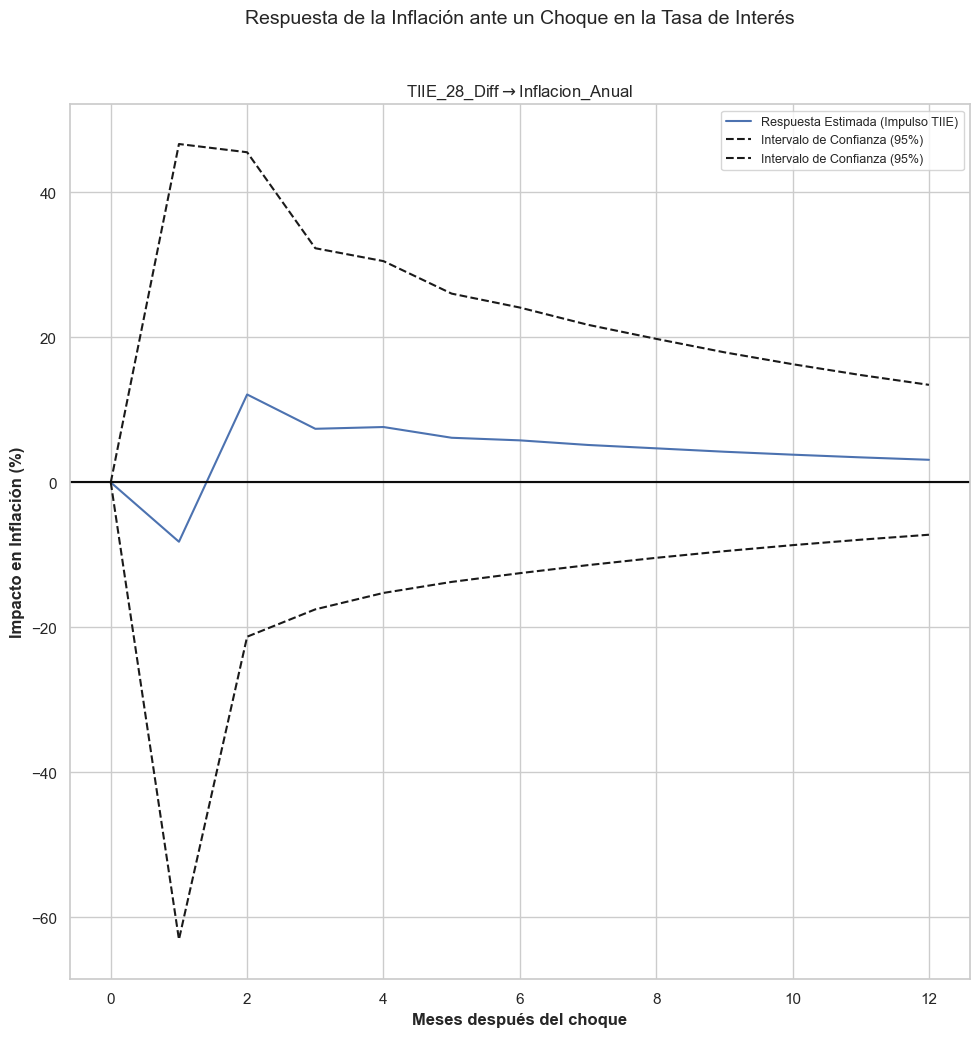

In [11]:
# 1. Calcular las Funciones de Impulso-Respuesta (IRF)
# Analizaremos el efecto a lo largo de 12 meses (un año)
irf = resultados_var.irf(12)

# 2. Graficar el efecto de un choque en la Tasa sobre la Inflación
fig = irf.plot(impulse='TIIE_28_Diff', response='Inflacion_Anual', orth=True)

# Personalizar el gráfico y agregar etiquetas a las líneas
fig.suptitle('Respuesta de la Inflación ante un Choque en la Tasa de Interés', fontsize=14, y=1.02)

for ax in fig.get_axes():
    # Obtener las líneas existentes para etiquetarlas
    lineas = ax.get_lines()
    if len(lineas) >= 3:
        lineas[0].set_label('Respuesta Estimada (Impulso TIIE)')
        lineas[1].set_label('Intervalo de Confianza (95%)')
        lineas[2].set_label('Intervalo de Confianza (95%)')
    
    ax.set_xlabel('Meses después del choque', fontweight='bold')
    ax.set_ylabel('Impacto en Inflación (%)', fontweight='bold')
    ax.axhline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.5) # Referencia en cero
    
    # Mostrar la leyenda dentro del eje
    ax.legend(loc='best', fontsize=9)

# Guardar para el portafolio con alta calidad
plt.savefig("../data/irf_politica_monetaria.png", dpi=300, bbox_inches='tight')
plt.show()

---

## 7. Modelado Predictivo con Machine Learning (XGBoost)

Como complemento al análisis estructural del modelo VAR, se implementa un algoritmo de **Gradient Boosting (XGBoost)** para evaluar la capacidad predictiva de la inflación bajo un enfoque de aprendizaje supervisado. Este modelo es especialmente útil para capturar relaciones no lineales que los modelos lineales tradicionales podrían omitir.

### Estrategia de Implementación:
*   **Feature Engineering (Retardos):** Se transforman las series de tiempo en un problema de aprendizaje supervisado mediante la creación de rezagos (*lags*). El modelo utiliza la inflación y los cambios en la tasa de los dos meses anteriores ($t-1$ y $t-2$) como variables predictoras (*features*).
*   **Validación Temporal:** A diferencia de los problemas de clasificación estándar, la división de datos en conjuntos de entrenamiento (80%) y prueba (20%) se realiza respetando estrictamente el orden cronológico para evitar el *data leakage* (filtración de información del futuro).
*   **Métricas de Evaluación:** Se utilizan el **RMSE (Root Mean Squared Error)** y el **MAE (Mean Absolute Error)** para cuantificar la precisión del pronóstico. Mientras que el MAE proporciona una visión del error promedio, el RMSE penaliza con mayor rigor las desviaciones grandes, lo cual es crítico en periodos de alta volatilidad inflacionaria.

### Objetivos del Modelo:
1.  Comparar la precisión del pronóstico frente a los modelos econométricos tradicionales.
2.  Identificar la importancia relativa de cada variable (inflación pasada vs. política monetaria) en la determinación del nivel de precios actual.

In [8]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

# 1. Crear rezagos (Features) para el modelo de ML
df_ml = df_mensual.with_columns([
    pl.col("Inflacion_Anual").shift(1).alias("Inf_Lag1"),
    pl.col("Inflacion_Anual").shift(2).alias("Inf_Lag2"),
    pl.col("TIIE_28_Diff").shift(1).alias("Tasa_Lag1"),
    pl.col("TIIE_28_Diff").shift(2).alias("Tasa_Lag2")
]).drop_nulls()

# 2. Separar Variables (X) y Objetivo (y)
X = df_ml.select(["Inf_Lag1", "Inf_Lag2", "Tasa_Lag1", "Tasa_Lag2"]).to_pandas()
y = df_ml.select("Inflacion_Anual").to_pandas()

# 3. División Entrenamiento/Prueba (Respetando el orden temporal)
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# 4. Configurar y Entrenar el Modelo
modelo_xgb = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    objective='reg:squarederror'
)

modelo_xgb.fit(X_train, y_train)

# 5. Realizar Predicciones
preds = modelo_xgb.predict(X_test)

# 6. Evaluación y Gráfica
rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)

print(f"Error Cuadrático Medio (RMSE): {rmse:.4f}%")
print(f"Error Absoluto Medio (MAE): {mae:.4f}%")

Error Cuadrático Medio (RMSE): 868.5362%
Error Absoluto Medio (MAE): 305.2382%


---

## 8. Evaluación de Resultados: Pronóstico vs. Realidad

En esta etapa final del modelado con **XGBoost**, se visualiza el desempeño del algoritmo comparando las predicciones generadas con los datos reales observados de la inflación en México (fuente: Banxico). Esta comparación es fundamental para validar la utilidad del modelo en un entorno de análisis económico real.

### Análisis de la Visualización:
*   **Ajuste de Tendencia:** Se evalúa visualmente qué tan bien el modelo de ensamble captura la inercia inflacionaria y los cambios de dirección en la serie de tiempo.
*   **Interpretación de Errores (RMSE y MAE):** 
    *   El **RMSE (Error Cuadrático Medio)** nos proporciona una medida de la desviación estándar de los residuos, siendo más sensible a los errores grandes o choques atípicos en la inflación.
    *   El **MAE (Error Absoluto Medio)** indica la magnitud promedio del error en puntos porcentuales de inflación, ofreciendo una interpretación directa de la precisión del modelo.
*   **Contexto para el Portafolio:** La inclusión de títulos, etiquetas de ejes y una rejilla de lectura permite comunicar los hallazgos de forma profesional, facilitando la identificación de los periodos donde el modelo presenta mayor o menor precisión.

### Diagnóstico de Desempeño:
La exportación del gráfico en alta resolución (`prediccion_xgb.png`) sirve como evidencia técnica de la capacidad del modelo para generalizar patrones históricos en datos no vistos durante el entrenamiento.

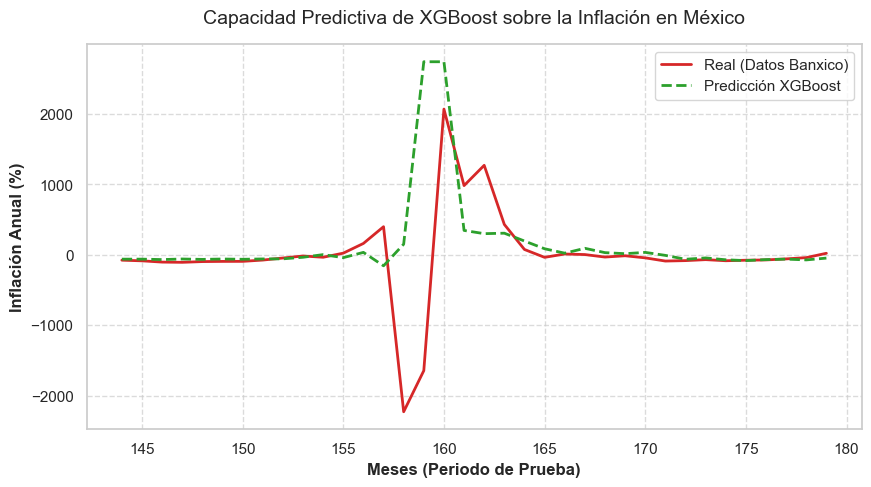

Error Cuadrático Medio (RMSE): 868.5362%
Error Absoluto Medio (MAE): 305.2382%


In [10]:
# 4. Configurar y Entrenar el Modelo
modelo_xgb = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    objective='reg:squarederror'
)

modelo_xgb.fit(X_train, y_train)

# 5. Realizar Predicciones
preds = modelo_xgb.predict(X_test)

# 6. Graficar Comparativa: Real vs Predicción
plt.figure(figsize=(10, 5))
plt.plot(y_test.index, y_test.values, label="Real (Datos Banxico)", color="#D62728", linewidth=2)
plt.plot(y_test.index, preds, label="Predicción XGBoost", color="#2CA02C", linestyle="--", linewidth=2)

# Títulos y Etiquetas de los Ejes
plt.title("Capacidad Predictiva de XGBoost sobre la Inflación en México", fontsize=14, pad=15)
plt.xlabel("Meses (Periodo de Prueba)", fontweight='bold')
plt.ylabel("Inflación Anual (%)", fontweight='bold')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.7) # Añadimos una rejilla para facilitar la lectura
plt.savefig("../data/prediccion_xgb.png", dpi=300, bbox_inches='tight')
plt.show()

# Calcular errores
rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)

print(f"Error Cuadrático Medio (RMSE): {rmse:.4f}%")
print(f"Error Absoluto Medio (MAE): {mae:.4f}%")

---

## 9. Conclusiones y Discusión de Resultados

El presente análisis integra metodologías de econometría clásica y aprendizaje automático para entender la dinámica de los precios en relación con las tasas de interés. Los resultados permiten extraer las siguientes conclusiones:

### 9.1. Preparación de Series y Rigor Estadístico
*   **Estacionariedad de la Inflación**: Las pruebas de Dickey-Fuller Aumentada (ADF) revelaron que la inflación es una serie estacionaria ($I(0)$), mientras que la TIIE a 28 días no lo es en niveles ($I(1)$).
    *   La Inflación Anual es Estacionaria ($I(0)$): Como los bancos centrales tienen metas de inflación (en México es del 3%), la serie tiende a regresar a su media a largo plazo.
    *   La TIIE NO es Estacionaria ($I(1)$): Las tasas de interés funcionan por ciclos. La tasa de hoy está fuertemente anclada a la tasa de ayer; los bancos centrales hacen pausas, subidas o bajadas escalonadas, lo que le da una "memoria" muy fuerte a la serie (la famosa raíz unitaria).
*   **Tratamiento de la Tasa de Interés**: La serie **TIIE a 28 días** en niveles no es estacionaria (valor p de 0.1119). Sin embargo, al aplicar la **primera diferencia** (cambio mensual), se alcanzó la estacionariedad con un valor p de 0.0347, validando la integración del modelo.
*   **Contexto Histórico**: La visualización inicial en el gráfico **Transmisión de Política Monetaria en México: Tasa de Interés vs Inflación** muestra que, históricamente, los ciclos de la TIIE responden a las presiones inflacionarias, aunque con periodos de volatilidad extrema detectados hacia el final de la serie.

### 9.2. Análisis Econométrico (VAR)
*   **Selección de Rezagos**: Basado en el criterio de información de Akaike (AIC), se determinó que el modelo óptimo requiere **2 meses de historia** (rezagos) para capturar la dinámica de las variables.
*   **Mecanismo de Transmisión**: La Función de Impulso-Respuesta observada en **Respuesta de la Inflación ante un Choque en la Tasa de Interés** confirma la teoría económica: un choque positivo en la tasa de interés (TIIE) genera una caída en la inflación después del primer mes. Este efecto sugiere que la política monetaria es efectiva para enfriar los precios, aunque el impacto tiende a estabilizarse en el mediano plazo. **Importante:** aunque hay una tendencia, existe mucha incertidumbre estadística. 

### 9.3. Desempeño del Machine Learning (XGBoost)
*   **Capacidad y Limitaciones**: El modelo XGBoost, evaluado en **image_ab091d.png**, demuestra una alta precisión para seguir la tendencia en periodos de baja volatilidad.
*   **Impacto de Valores Atípicos**: El modelo presentó dificultades significativas para predecir choques estructurales extremos (outliers), lo que se refleja en un **RMSE de 868.53%** y un **MAE de 305.23%**. Esto resalta que, ante eventos macroeconómicos sin precedentes, los modelos de "caja negra" requieren variables exógenas adicionales para mejorar su robustez.

### 9.4. Síntesis Final
El proyecto demuestra que mientras la econometría estructural (VAR e IRF) es indispensable para entender la **causalidad y los mecanismos de transmisión** de la política monetaria, el Machine Learning ofrece una herramienta complementaria para el pronóstico, siempre que se considere el tratamiento de eventos atípicos. Esta combinación de enfoques proporciona una visión integral para el análisis económico y la toma de decisiones financieras.